# Classificação Utilizando EuRepoC dataset

##  Previsão de Ciberataques com Inteligência Artificial (K-NN)
**Análise e Modelagem Preditiva usando a base de dados do EuRepoC**

Este projeto tem como objetivo analisar incidentes cibernéticos globais e construir um modelo de Machine Learning capaz de classificar e prever o Tipo de Incidente (ex: Data theft, Disruption, Hijacking) com base nas características do ataque, como país de origem, tipo de alvo e método de atribuição.


## Importação das Libs e Carregamento dos dados

In [8]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split


try:
  dataset = pd.read_csv('./eurepoc_global_dataset_1_3.csv')
  print(f"Tamanho original da base: {dataset.shape}")
  display(dataset.head())
except Exception as e:
  print(f'Error reading file "{dataset}": {e}')

Tamanho original da base: (3414, 85)


,incident_id,name,description,start_date,end_date,inclusion_criterion,inclusion_criterion_subcode,source_disclosure,incident_type,receiver_name,...,legal_response_subtype,legal_response_responding_country,legal_response_responding_actor,attribution_legal_reference,attribution_legal_reference_subcode,response_indicator,casualties,source_url,added_to_db,updated_at
0,4163,Russian State-Sponsored Actors Linked to GRU ...,"On 19 December 2024, a cyber attack attributed...",19.12.2024,19.12.2024,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Disruption;Hijacking with Misuse,Ministry of Justice (Ukraine),...,Not available,Ukraine,Security Service of Ukraine (SBU),Not available,Not available,Countermeasures under international law justif...,Not available,https://www.t-online.de/nachrichten/ukraine/id...,2024-12-23,2025-02-18
1,4161,Unknown threat actors stole Microsoft Azure ac...,Unit 42 researchers uncovered a phishing campa...,01.06.2024,Not available,Attack on critical infrastructure target(s),Not available,Incident disclosed by IT-security company,Data theft;Hijacking with Misuse,Not available;Not available;Not available;Not ...,...,Not available,Not available,Not available,Not available,Not available,Unfriendly acts/retorsions justified (missing ...,Not available,https://www.bleepingcomputer.com/news/security...,2024-12-20,2025-02-18
2,4160,Unspecified US intelligence agencies stole tra...,The Chinese National Internet Emergency Respon...,01.05.2023,Not available,Attack conducted by nation state (generic “sta...,Not available,Incident disclosed by authorities of victim state,Data theft;Hijacking with Misuse,Not available,...,Not available,Not available,Not available,Not available,Not available,Countermeasures under international law justif...,Not available,https://cyberscoop.com/chinese-cyber-center-us...,2024-12-20,2025-02-18
3,4159,Unspecified US intelligence agency stole trade...,The Chinese National Internet Emergency Respon...,01.08.2024,Not available,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Data theft;Hijacking with Misuse,Not available;Not available,...,Not available,Not available,Not available,Not available,Not available,Countermeasures under international law justif...,Not available,https://cyberscoop.com/chinese-cyber-center-us...,2024-12-20,2025-02-18
4,4158,Unknown Threat Actors breached the Attorney Ge...,"In March 2024, a hacker breached the computer ...",01.03.2024,Not available,"Attack on (inter alia) political target(s), no...",Not available,Not available,Data theft & Doxing;Hijacking with Misuse,Attorney General's Office of Nuevo León,...,Not available,Not available,Not available,Not available,Not available,Unfriendly acts/retorsions justified (missing ...,Not available,https://mvsnoticias.com/nuevo-leon/2024/12/18/...,2024-12-20,2025-02-04


## Análise dos dados coletados

Antes de aplicar qualquer modelo matemático, precisamos entender o comportamento das ameaças ao longo do tempo.

As visualizações abaixo respondem a duas perguntas cruciais:
1. O volume de ciberataques está crescendo com o passar dos anos?
2. Quais são as tendências atuais? (Ex: Houve uma explosão recente de Roubo de Dados ou Interrupção de Sistemas?)




Gerando visualizações exploratórias...


/tmp/ipykernel_49121/1179876709.py:4: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset['start_date'] = pd.to_datetime(dataset['start_date'], errors='coerce')


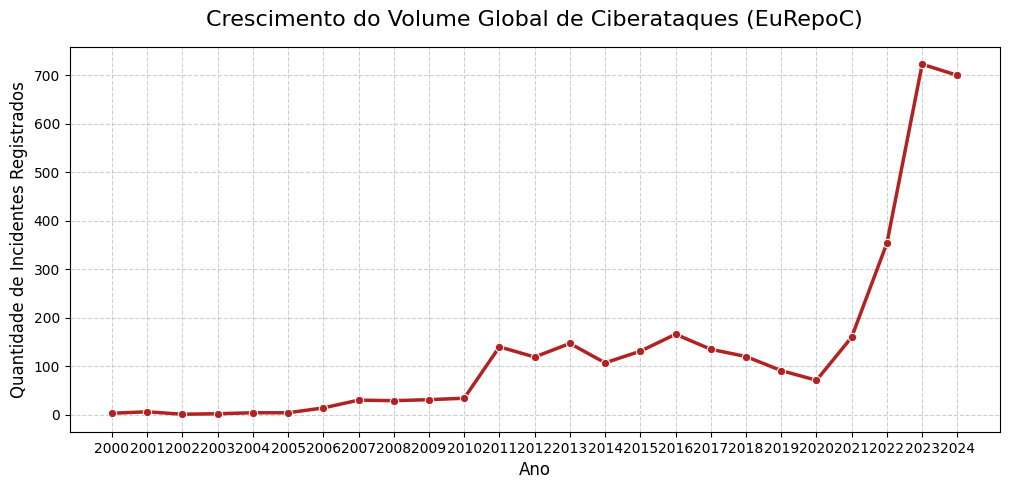

In [9]:
print("\nGerando visualizações exploratórias...")

# Formato de data do Python e extraindo o Ano
dataset['start_date'] = pd.to_datetime(dataset['start_date'], errors='coerce')
dataset['Ano'] = dataset['start_date'].dt.year

# Criando uma coluna temporária com os nomes dos ataques limpos (apenas para o gráfico)
dataset['tipo_grafico'] = dataset['incident_type'].apply(lambda x: str(x).split(';')[0].split('&')[0].strip())

df_graficos = dataset[dataset['Ano'] >= 2000]

plt.figure(figsize=(12, 5))
ataques_por_ano = df_graficos['Ano'].value_counts().sort_index()

sns.lineplot(x=ataques_por_ano.index, y=ataques_por_ano.values, marker='o', color='firebrick', linewidth=2.5)

plt.title('Crescimento do Volume Global de Ciberataques (EuRepoC)', fontsize=16, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Incidentes Registrados', fontsize=12)
plt.xticks(ataques_por_ano.index) # Garante que todos os anos apareçam no eixo X
plt.grid(True, linestyle='--', alpha=0.6)
#plt.tight_layout()
#plt.show()

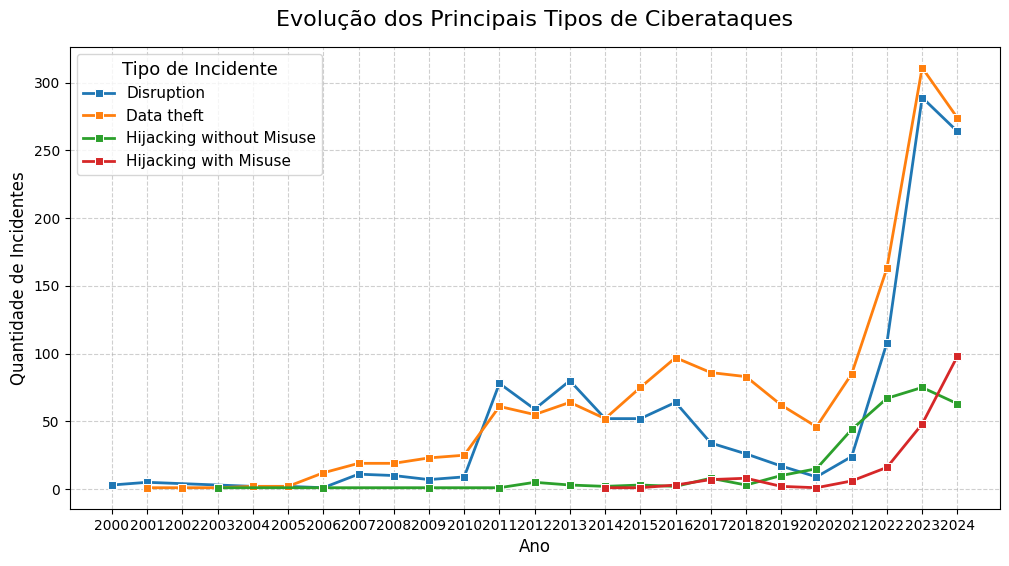

In [10]:
# Pegando apenas os 4 ataques mais comuns para o gráfico não virar uma "salada" de linhas
top_4_ataques = df_graficos['tipo_grafico'].value_counts().head(4).index
df_top_ataques = df_graficos[df_graficos['tipo_grafico'].isin(top_4_ataques)]

# Contando a quantidade de cada ataque por ano
evolucao_tipos = df_top_ataques.groupby(['Ano', 'tipo_grafico']).size().reset_index(name='Quantidade')

plt.figure(figsize=(12, 6))
sns.lineplot(data=evolucao_tipos, x='Ano', y='Quantidade', hue='tipo_grafico', marker='s', linewidth=2)

plt.title('Evolução dos Principais Tipos de Ciberataques', fontsize=16, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Incidentes', fontsize=12)
plt.xticks(ataques_por_ano.index)
plt.legend(title='Tipo de Incidente', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
#plt.tight_layout()
#plt.show()

## Seleção de Colunas: Isolamos apenas as características (features) relevantes para o modelo

In [11]:
colunas_de_interesse = [
  'incident_type',
  'receiver_regions',
  'receiver_category',
  'initiator_category',
  'mitre_initial_access',
  'impact_indicator_score',
  'user_interaction'
]

df_modelo = dataset[colunas_de_interesse].copy()
df_modelo.head()

,incident_type,receiver_regions,receiver_category,initiator_category,mitre_initial_access,impact_indicator_score,user_interaction
0,Disruption;Hijacking with Misuse,"['EUROPE', 'EASTEU']",State institutions / political system,State,Not available,8,Not available
1,Data theft;Hijacking with Misuse,"['EUROPE', 'NATO', 'EU', 'WESTEU'];['EUROPE', ...",Critical infrastructure;Corporate Targets (cor...,Not attributed,Phishing,6,Not available
2,Data theft;Hijacking with Misuse,"['ASIA', 'SCS', 'EASIA', 'NEA', 'SCO']",Corporate Targets (corporate targets only code...,State,Exploit Public-Facing Application,6,Not available
3,Data theft;Hijacking with Misuse,"['ASIA', 'SCS', 'EASIA', 'NEA', 'SCO'];['ASIA'...",Corporate Targets (corporate targets only code...,State,Exploit Public-Facing Application,6,Not available
4,Data theft & Doxing;Hijacking with Misuse,['Not available'],State institutions / political system,Not attributed,Not available,7,Not available


## Removemos registros sem o tipo de incidente definido

In [12]:
df_modelo = df_modelo.dropna(subset=['incident_type'])
df_modelo = df_modelo[df_modelo['incident_type'] != 'Not available']

df_modelo['impact_indicator_score'] = df_modelo['impact_indicator_score'].fillna(0)

print(df_modelo['incident_type'])

0                Disruption;Hijacking with Misuse
1                Data theft;Hijacking with Misuse
2                Data theft;Hijacking with Misuse
3                Data theft;Hijacking with Misuse
4       Data theft & Doxing;Hijacking with Misuse
                          ...                    
3409                                   Disruption
3410                                   Disruption
3411                                   Disruption
3412                                   Disruption
3413                                   Disruption
Name: incident_type, Length: 3411, dtype: str


## Agrupamos categorias complexas e removemos ataques extremamente raros  para evitar ruído matemático e focar nas ameaças estatisticamente relevantes


In [13]:
# Simplificando as classes
for coluna in ['incident_type', 'receiver_category', 'mitre_initial_access']:
  df_modelo[coluna] = df_modelo[coluna].apply(lambda x: str(x).split(';')[0].strip())
  df_modelo[coluna] = df_modelo[coluna].apply(lambda x: str(x).split('&')[0].strip())

df_modelo['receiver_category'] = df_modelo['receiver_category'].apply(lambda x: str(x).split(';')[0].strip())
df_modelo['receiver_category'] = df_modelo['receiver_category'].apply(lambda x: str(x).split('/')[0].strip())

# Remover classes raras
contagem_classes = df_modelo['incident_type'].value_counts()
classes_frequentes = contagem_classes[contagem_classes >= 5].index
df_modelo = df_modelo[df_modelo['incident_type'].isin(classes_frequentes)]

print("Distribuição das novas classes simplificadas:")
print(df_modelo['incident_type'].value_counts())

Distribuição das novas classes simplificadas:
incident_type
Data theft                  1675
Disruption                  1212
Hijacking without Misuse     326
Hijacking with Misuse        197
Name: count, dtype: int64


## One-Hot Encoding




In [14]:
X = df_modelo.drop(columns=['incident_type'])
y = df_modelo['incident_type']

X = X.fillna('Desconhecido').replace('Not available', 'Desconhecido')
X = X.astype(str)

X_codificado = pd.get_dummies(X, drop_first=True)
X_codificado = X_codificado.fillna(0) 


print(f"Tamanho após pré-processamento (X): {X_codificado.shape}")

X_treino, X_teste, y_treino, y_teste = train_test_split(X_codificado, y, test_size=0.2, random_state=42)

Tamanho após pré-processamento (X): (3410, 730)


## SMOTE

In [ ]:
#smote = SMOTE(random_state=42)

#X_treino_smote, y_treino_smote = smote.fit_resample(X_treino, y_treino)

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

## GridSearch e Prevenção de Vazamento de Dados

In [16]:
print("Iniciando o GridSearch... Treinando múltiplos modelos...\n")

# Valores de K a testar
parametros_para_testar = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

Iniciando o GridSearch... Treinando múltiplos modelos...



## Validação Cruzada e Execução do KNN

In [18]:
knn_base = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator= knn_base,
    param_grid= parametros_para_testar,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_treino, y_treino)

# Resultados do melhor vizinho
melhor_vizinho = grid_search.best_params_['n_neighbors']
melhor_peso = grid_search.best_params_['weights']

melhor_modelo = grid_search.best_estimator_

y_pred_teste_simples = melhor_modelo.predict(X_teste)

print(f"O melhor número de vizinhos (K) é: {melhor_vizinho}")
print(f"O melhor sistema de pesos é: {melhor_peso}")
print(f"Acurácia no Teste Simples: {accuracy_score(y_teste, y_pred_teste_simples):.8f}")
print("-" * 50)

print("\n")

# Cross Validation
y_pred_cross_val = cross_val_predict(melhor_modelo, X_codificado, y, cv=5)

# Avaliação Final do KNN
print("\n=== RESULTADOS DO MODELO OTIMIZADO ===")
print(f"Acurácia na Validação Cruzada: {accuracy_score(y, y_pred_cross_val):.8f}")
print("\nRelatório de Classificação Detalhado:\n")
print(classification_report(y, y_pred_cross_val))

O melhor número de vizinhos (K) é: 7
O melhor sistema de pesos é: uniform
Acurácia no Teste Simples: 0.63049853
--------------------------------------------------



=== RESULTADOS DO MODELO OTIMIZADO ===
Acurácia na Validação Cruzada: 0.60263930

Relatório de Classificação Detalhado:

                          precision    recall  f1-score   support

              Data theft       0.63      0.72      0.67      1675
              Disruption       0.59      0.57      0.58      1212
   Hijacking with Misuse       0.25      0.16      0.19       197
Hijacking without Misuse       0.65      0.36      0.46       326

                accuracy                           0.60      3410
               macro avg       0.53      0.45      0.48      3410
            weighted avg       0.59      0.60      0.59      3410



## Matriz de Confusão

A Matriz de Confusão é a apresentação executiva do nosso modelo.
* **Diagonal Principal (Azul Escuro):** Representa os nossos acertos categóricos.
* **Fora da Diagonal:** Mostra onde o modelo está se confundindo. Devido ao desbalanceamento natural da base (muitos casos de *Data theft* e poucos de *Hijacking*), é esperado que o modelo favoreça as classes majoritárias em situações de dúvida.

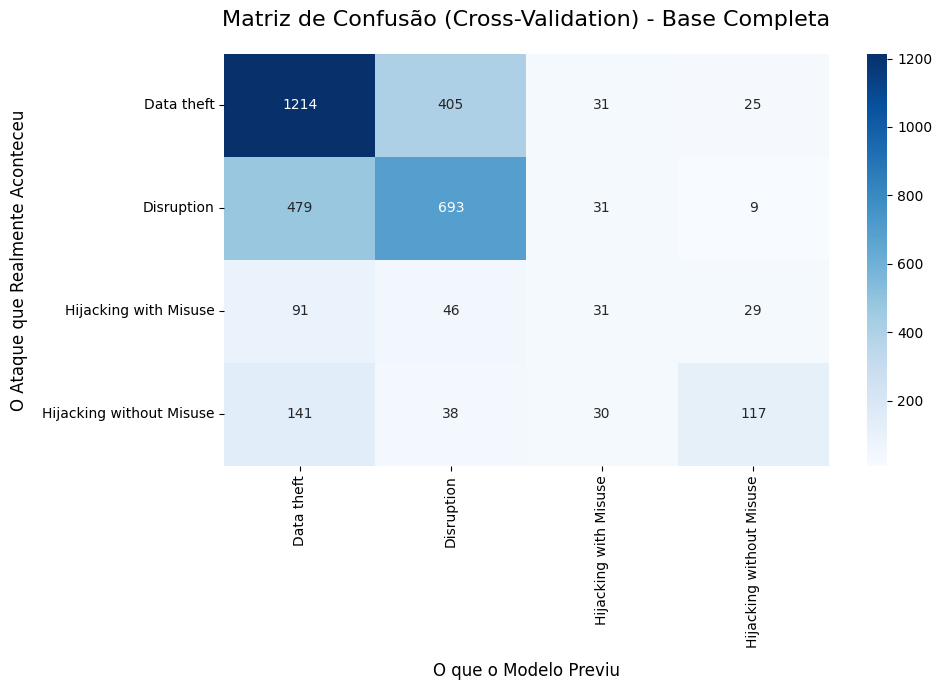

In [19]:
matriz_confusao = confusion_matrix(y, y_pred_cross_val)

nomes_das_classes = melhor_modelo.classes_

plt.figure(figsize=(10, 7))

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_das_classes, yticklabels=nomes_das_classes)
plt.title('Matriz de Confusão (Cross-Validation) - Base Completa', fontsize=16, pad=20)
plt.xlabel('O que o Modelo Previu', fontsize=12, labelpad=10)
plt.ylabel('O Ataque que Realmente Aconteceu', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()